In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
TEST_DIR = r"C:\Users\Abdullah\00 ML\projects\data\seg_test\seg_test"

In [3]:
os.listdir(TEST_DIR)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [4]:
import cv2

X, y = [], []
label_map = {}
label_id = 0

for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    label_map[class_name] = label_id

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)

        if img is None:
            continue
        #print(img.shape)
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        
       # print(img.shape)
        X.append(img.flatten())
        y.append(label_id)

    label_id += 1

In [5]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)  

(3000, 30000)


In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def run_experiment(X, y, sample_sizes):
    results = []

    for sample_size in sample_sizes:
        print(f"\n===== Sample Size: {sample_size} =====")

        np.random.seed(42)

        # Sample subset
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X[indices]
        y_sample = y[indices]

        X_train, X_test, y_train, y_test = train_test_split(
            X_sample, y_sample,
            test_size=0.2,
            random_state=42,
            stratify=y_sample
        )

        param_grid = {
            'criterion': ['gini'],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }

        grid = GridSearchCV(
            DecisionTreeClassifier(random_state=42),
            param_grid,
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_dt = grid.best_estimator_

        # Evaluate
        y_pred = best_dt.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        print("Best Params:", grid.best_params_)
        print("Test Accuracy:", acc)

        results.append((sample_size, acc, grid.best_params_))

    return results, best_dt

In [7]:
sample_sizes = [100, 200, 500, 1000, 2000, 3000]

results, best_dt = run_experiment(X, y, sample_sizes)


===== Sample Size: 100 =====
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Test Accuracy: 0.2

===== Sample Size: 200 =====
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.475

===== Sample Size: 500 =====
Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Test Accuracy: 0.4

===== Sample Size: 1000 =====
Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.375

===== Sample Size: 2000 =====
Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Test Accuracy: 0.3875

===== Sample Size: 3000 =====
Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Test Accuracy: 0.44166666666666665


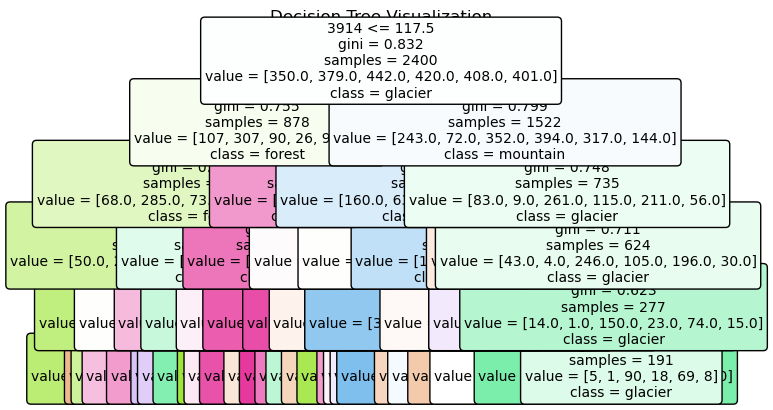

In [10]:
from sklearn.tree import plot_tree

plot_tree(
    best_dt,
    filled=True,
    feature_names= np.arange(0, 30000),
    class_names= os.listdir(TEST_DIR),      
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
sizes = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.plot(sizes, accuracies, marker='o')
plt.xlabel("Sample Size")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs Sample Size")
plt.grid()
plt.show()